<a href="https://colab.research.google.com/github/vascon01/Projeto-Integrador/blob/main/Introdu%C3%A7%C3%A3o_a_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
#Começo do estudo as 12:30
https://www.youtube.com/watch?v=JyGGMyR3x5I
#Como identificar um porco ou um cachorro
#sim(1) nao(0)
#pelo longo?
#perna curta?
#late?

In [58]:
porco_1=[0,1,0] #Esse porco ele não tem pelo longo,tem perna curta e não late
porco_2=[0,1,0]
porco_3=[0,1,0]

In [59]:
carrocho_1=[1,1,1]
carrocho_2=[0,1,1]
carrocho_3=[1,0,1]

In [60]:
treino_x=[porco_1,porco_2,porco_3,carrocho_1,carrocho_2,carrocho_3]

In [61]:
treino_y=[1,1,1,0,0,0] #Porco 1 Cachorro 2 Esse valor binario nao tem relação com a classificação

In [62]:
#Meu objetivo é pegar uma função que ao adicior os valores eu descubro se é porco ou cachorro

In [63]:
from sklearn.svm import LinearSVC

modelo=LinearSVC() #Seria como se fosse o cerebro vazio
modelo.fit(treino_x,treino_y) #Encaixa esses valores no cerebro

LinearSVC()

In [64]:
animal_misterioso=[1,1,1] #Cachorro
modelo.predict([animal_misterioso])

array([0])

In [65]:
animal_misterioso_2=[0,1,0] #Porco
modelo.predict([animal_misterioso_2])

array([1])

In [66]:
#Pausa pra almoçar 12:52 volta 13:10
mist_1=[1,1,1]
mist_2=[1,1,0]
mist_3=[0,1,1]
teste_x=[mist_1,mist_2,mist_3]
teste_y=[0,1,1]

In [67]:
previsoes=modelo.predict(teste_x)
previsoes #Porco

array([0, 1, 0])

In [68]:
from sklearn.metrics import accuracy_score

accuracy_score(teste_y,previsoes)

0.6666666666666666

# Parte dois
https://www.youtube.com/watch?v=SvmFqZ4cD-I

In [71]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("cherngs/heart-disease-cleveland-uci")

print("Path to dataset files:", path)

100%|██████████| 3.33k/3.33k [00:00<00:00, 5.58MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/cherngs/heart-disease-cleveland-uci/versions/1


In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
df=pd.read_csv("/content/heart_cleveland_upload.csv")

In [75]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [87]:
df["condition"].value_counts()

,count
condition,
0,160
1,137


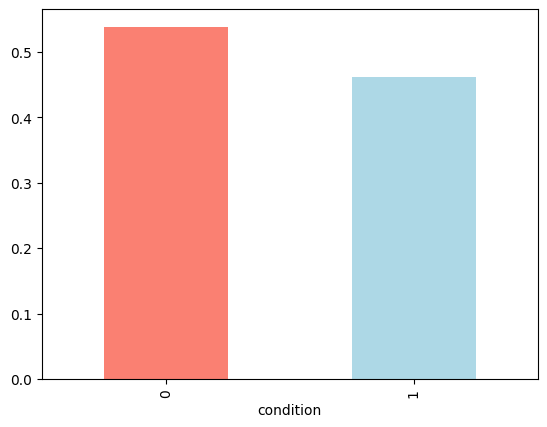

In [89]:
df["condition"].value_counts(normalize=True).plot(kind="bar", color=["salmon", "lightblue"]);


In [90]:
pd.crosstab(df["condition"], df["sex"])

sex,0,1
condition,,
0,71,89
1,25,112


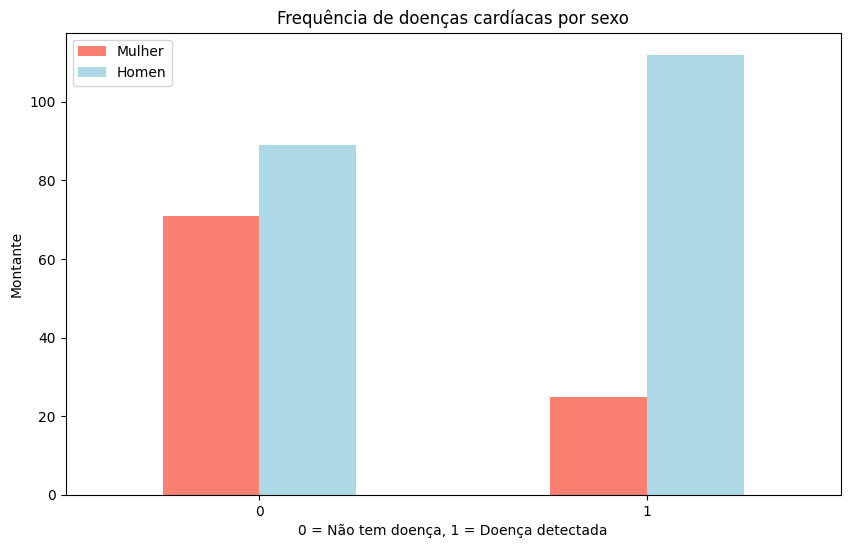

In [92]:
pd.crosstab(df["condition"], df["sex"]).plot(kind="bar", figsize=(10,6), color=["salmon", "lightblue"])
# Adicionando atributos
plt.title("Frequência de doenças cardíacas por sexo")
plt.xlabel("0 = Não tem doença, 1 = Doença detectada")
plt.ylabel("Montante")
plt.legend(["Mulher", "Homen"])
plt.xticks(rotation=0); # configura os eixos dos labels para vertical


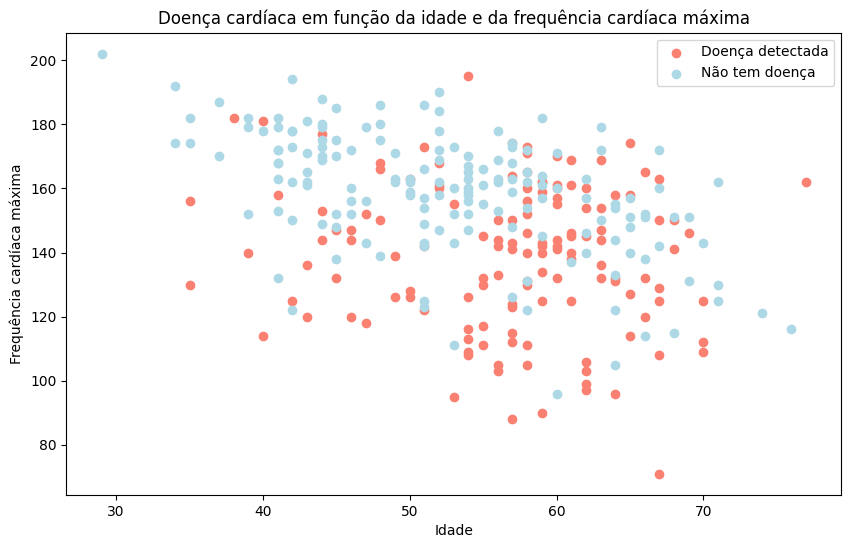

In [93]:

plt.figure(figsize=(10,6))

# Plot para valores positivos
plt.scatter(df["age"][df["condition"] ==1 ],
            df["thalach"][df["condition"] == 1],
            c="salmon")

# Plot para valores negativos
# queremos plotar no mesmo gráfico então não vamos configurar axes diferentes
plt.scatter(df["age"][df["condition"] == 0],
            df["thalach"][df["condition"] == 0],
            c="lightblue")

# Atributos
plt.title("Doença cardíaca em função da idade e da frequência cardíaca máxima")
plt.xlabel("Idade")
plt.legend(["Doença detectada", "Não tem doença"])
plt.ylabel("Frequência cardíaca máxima");

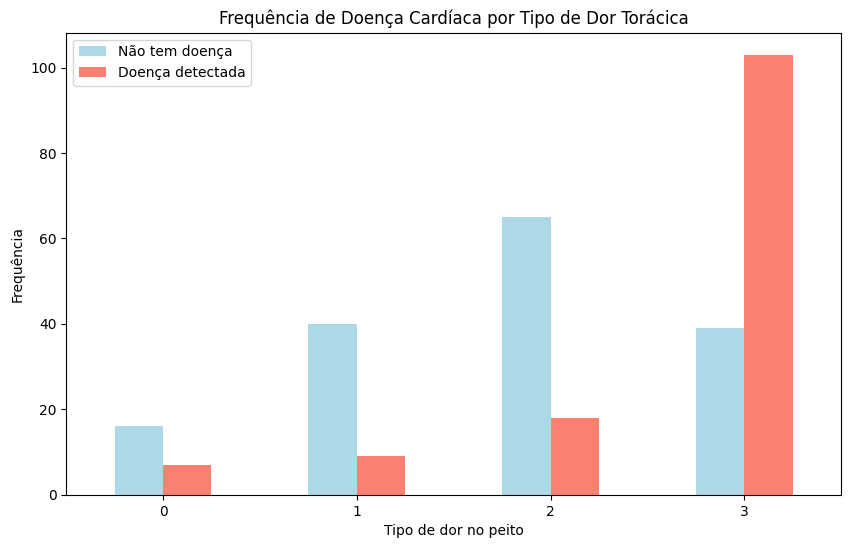

In [94]:
pd.crosstab(df["cp"], df["condition"]).plot(kind="bar",
                                   figsize=(10,6),
                                   color=["lightblue", "salmon"])

# Adicionando atributos ao gráfico
plt.title("Frequência de Doença Cardíaca por Tipo de Dor Torácica")
plt.xlabel("Tipo de dor no peito")
plt.ylabel("Frequência")
plt.legend(["Não tem doença", "Doença detectada"])
plt.xticks(rotation = 0);

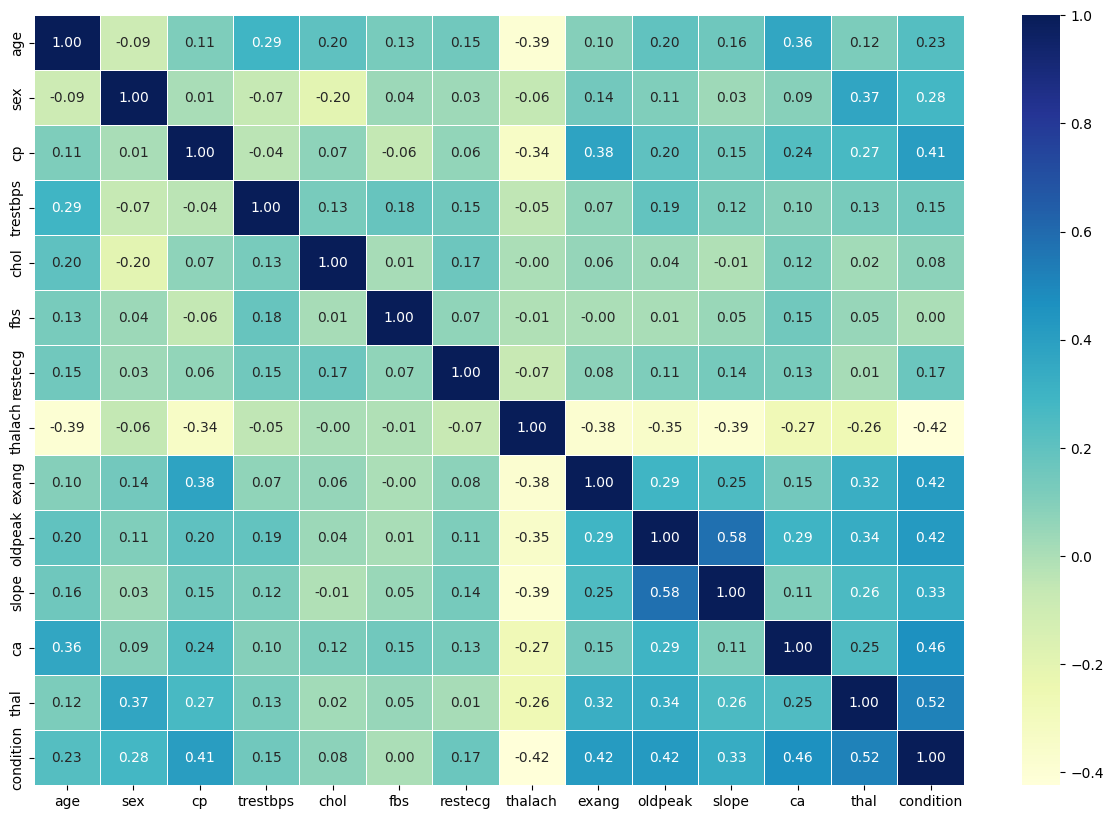

In [95]:
import seaborn as sns

corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=True,
            linewidths=0.5,
            fmt= ".2f",
            cmap="YlGnBu");

In [96]:
#Modelagem dos dados:

In [99]:
X=df.drop("condition",axis=1)
y=df["condition"]

In [98]:
X.head()#Basicamente tirei o condition

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0


In [100]:
y.head()

,condition
0,0
1,0
2,0
3,1
4,0


In [101]:
#Treino de teste:

In [102]:
from sklearn.model_selection import train_test_split

In [103]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2) #Separei 20 porcento dos dados pra teste e 80 pra treino

In [104]:
len(X_train), len(X_test)

(237, 60)

---

#Qual modelo eu tenho que escolher??


---
 ## No caso vou escolher 3 modelo
 - Randm forest Classifier
 - KNeigbors
 - Logistics


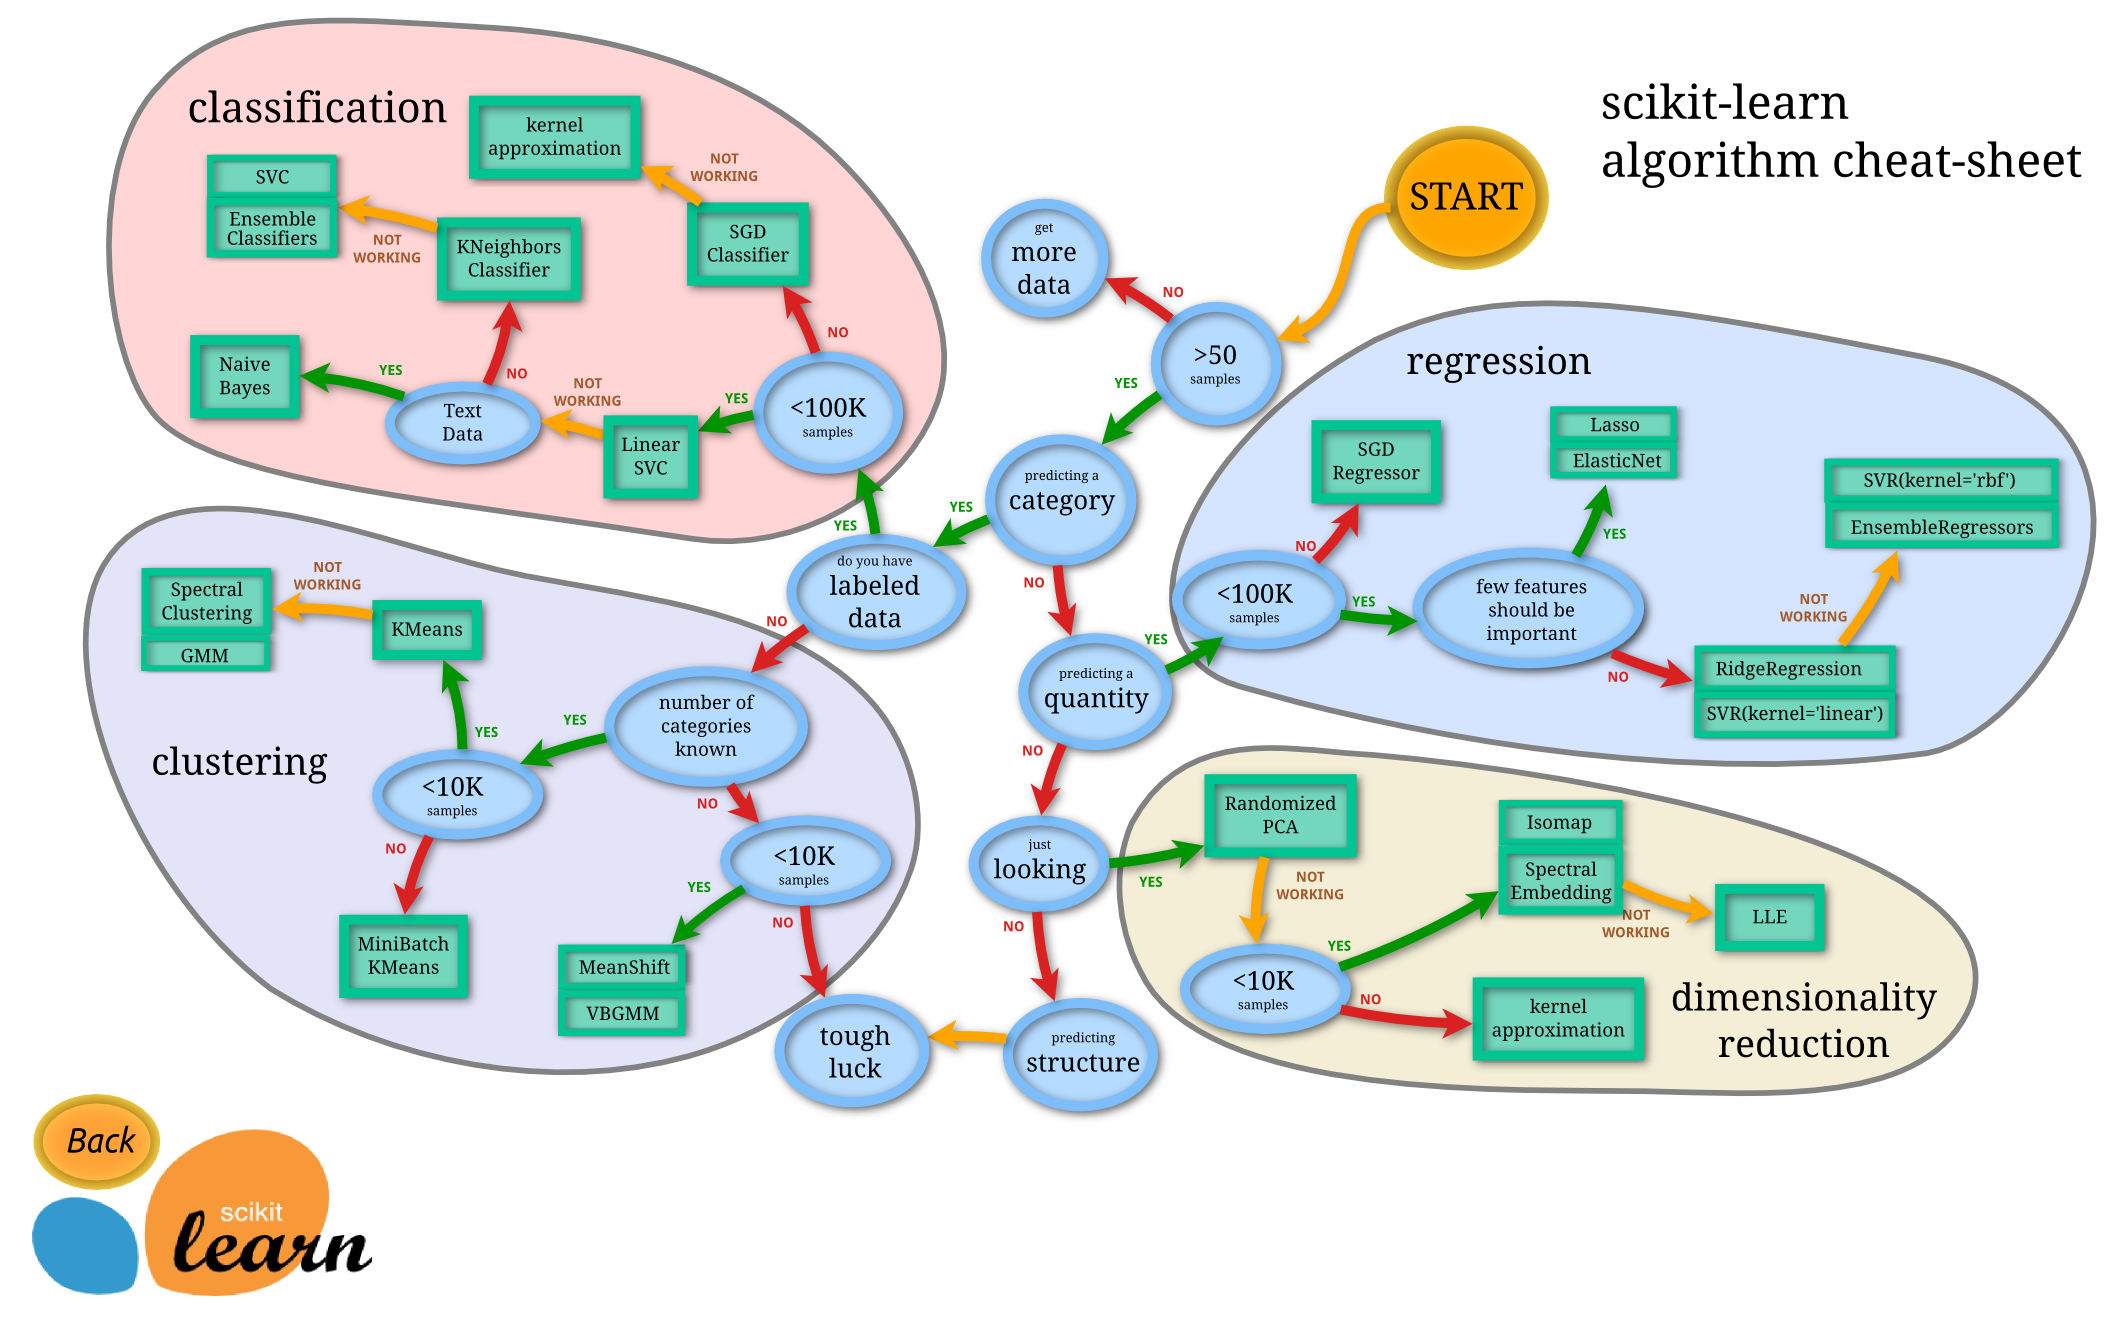

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [111]:
models = {"KNN": KNeighborsClassifier(),
           "Logistc Regression": LogisticRegression(max_iter=1000),
           "Random Forest": RandomForestClassifier()}

def fit_and_score(models, X_train, X_test, y_train, y_test):
  np.random.seed(42)

  model_scores = {}

  for name, model in models.items():
    model.fit(X_train, y_train)
    model_scores[name] = model.score(X_test, y_test)
  return model_scores

In [112]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

{'KNN': 0.6333333333333333,
 'Logistc Regression': 0.8666666666666667,
 'Random Forest': 0.8333333333333334}

In [113]:
#Parei no minuto 20 do video as 15 horas total: 1 hora e 50 min